In [1]:
# ============================================
# BLOCK 1: LOAD BEST MODEL AND EVALUATE
# Binary classification: 0=INTERMEDIARY, 1=HIGH
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

print("="*60)
print("MODEL EVALUATION AND INTERPRETATION")
print("Classes: 0=INTERMEDIARY, 1=HIGH  (LOW excluded by design)")
print("="*60)

processed_path = '../data/processed/'
best_model = joblib.load(f'{processed_path}best_model.pkl')

# Load clean data (binary: INTERMEDIARY=0, HIGH=1)
df = pd.read_csv(f'{processed_path}processed_data_clean.csv')
print(f"Data shape: {df.shape}")
print(f"Target distribution:")
print(df['CVD_Risk_Encoded'].value_counts().sort_index().rename({0:'INTERMEDIARY',1:'HIGH'}))

feature_cols = [col for col in df.columns if col != 'CVD_Risk_Encoded']
X = df[feature_cols]
y = df['CVD_Risk_Encoded'].astype(int)

# Same split as model building (random_state=42, stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTest set: {X_test.shape[0]} real samples")
print(f"Test distribution: {y_test.value_counts().sort_index().rename({0:'INTERMEDIARY',1:'HIGH'}).to_dict()}")

# Predictions - NO remapping needed (classes are already 0 and 1)
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
auc       = roc_auc_score(y_test, y_pred_proba[:,1])

print(f"\nBest Model Performance on Test Set:")
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}  ({f1*100:.2f}%)")
print(f"  AUC:       {auc:.4f}  ({auc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['INTERMEDIARY','HIGH']))


MODEL EVALUATION AND INTERPRETATION
Classes: 0=INTERMEDIARY, 1=HIGH  (LOW excluded by design)
Data shape: (1309, 33)
Target distribution:
CVD_Risk_Encoded
INTERMEDIARY    581
HIGH            728
Name: count, dtype: int64

Test set: 262 real samples
Test distribution: {'INTERMEDIARY': 116, 'HIGH': 146}

Best Model Performance on Test Set:
  Accuracy:  0.8130  (81.30%)
  Precision: 0.8126  (81.26%)
  Recall:    0.8130  (81.30%)
  F1-Score:  0.8127  (81.27%)
  AUC:       0.8997  (89.97%)

Classification Report:
              precision    recall  f1-score   support

INTERMEDIARY       0.80      0.78      0.79       116
        HIGH       0.83      0.84      0.83       146

    accuracy                           0.81       262
   macro avg       0.81      0.81      0.81       262
weighted avg       0.81      0.81      0.81       262




CONFUSION MATRIX


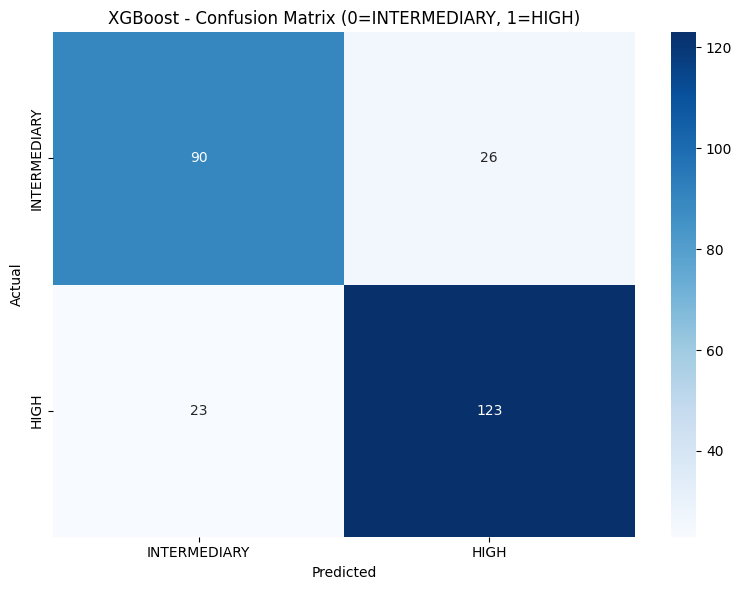


Confusion Matrix Details:
  True Negatives  (INTERMEDIARY predicted INTERMEDIARY): 90
  False Positives (INTERMEDIARY predicted HIGH):         26
  False Negatives (HIGH predicted INTERMEDIARY):         23
  True Positives  (HIGH predicted HIGH):                 123

  INTERMEDIARY precision: 79.6%
  HIGH precision:         82.6%


In [2]:
# BLOCK 2: CONFUSION MATRIX
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['INTERMEDIARY','HIGH'],
            yticklabels=['INTERMEDIARY','HIGH'])
plt.title('XGBoost - Confusion Matrix (0=INTERMEDIARY, 1=HIGH)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/best_model_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Details:")
print(f"  True Negatives  (INTERMEDIARY predicted INTERMEDIARY): {tn}")
print(f"  False Positives (INTERMEDIARY predicted HIGH):         {fp}")
print(f"  False Negatives (HIGH predicted INTERMEDIARY):         {fn}")
print(f"  True Positives  (HIGH predicted HIGH):                 {tp}")
print(f"\n  INTERMEDIARY precision: {tn/(tn+fn)*100:.1f}%")
print(f"  HIGH precision:         {tp/(tp+fp)*100:.1f}%")



ROC CURVE AND AUC


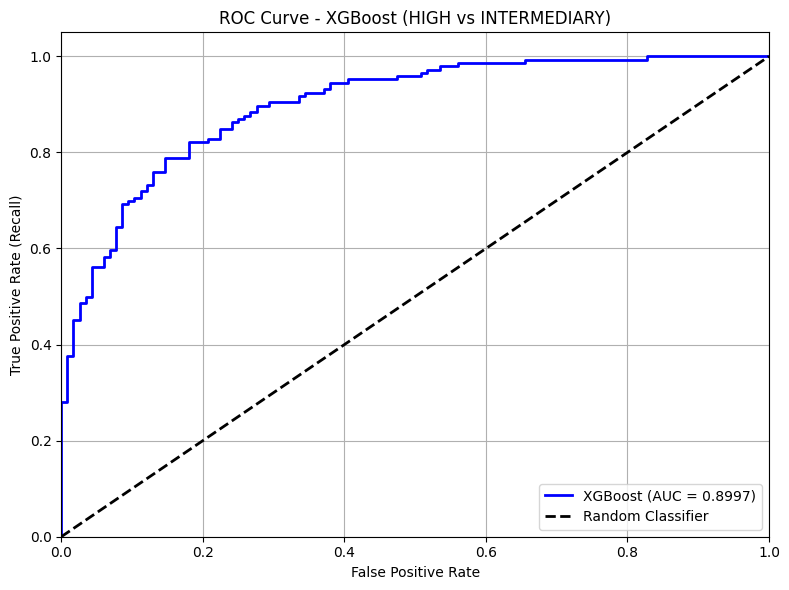


AUC Score: 0.8997  (89.97%)
  Good discrimination (AUC >= 0.80)


In [3]:
# BLOCK 3: ROC CURVE AND AUC
print("\n" + "="*60)
print("ROC CURVE AND AUC")
print("="*60)

# HIGH is class 1 — use column index 1 for positive class probabilities
y_proba_high = y_pred_proba[:, 1]  # probability of HIGH (class 1)
y_test_binary = y_test  # already binary: 0=INTERMEDIARY, 1=HIGH

fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba_high)
roc_auc = roc_auc_score(y_test_binary, y_proba_high)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - XGBoost (HIGH vs INTERMEDIARY)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('../images/best_model_roc_curves.png')
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}  ({roc_auc*100:.2f}%)")
if roc_auc >= 0.90:
    print("  Excellent discrimination (AUC >= 0.90)")
elif roc_auc >= 0.80:
    print("  Good discrimination (AUC >= 0.80)")
elif roc_auc >= 0.70:
    print("  Fair discrimination (AUC >= 0.70)")
else:
    print("  Poor discrimination (AUC < 0.70)")



FINAL FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
                      Feature  Importance
       Smoking Status_Encoded    0.075472
                  Age_Elderly    0.061497
               CVD Risk Score    0.057039
Family History of CVD_Encoded    0.056551
                 Obesity_Risk    0.050679
      Diabetes Status_Encoded    0.044747
    Physical_Activity_Encoded    0.042087
                          Age    0.039503
                   BMI_Normal    0.039086
                    BMI_Obese    0.038921
                   Age_Senior    0.034156
              BMI_Underweight    0.033038
                  HDL (mg/dL)    0.030827
              Metabolic_Score    0.028863
                   Age_Middle    0.026796


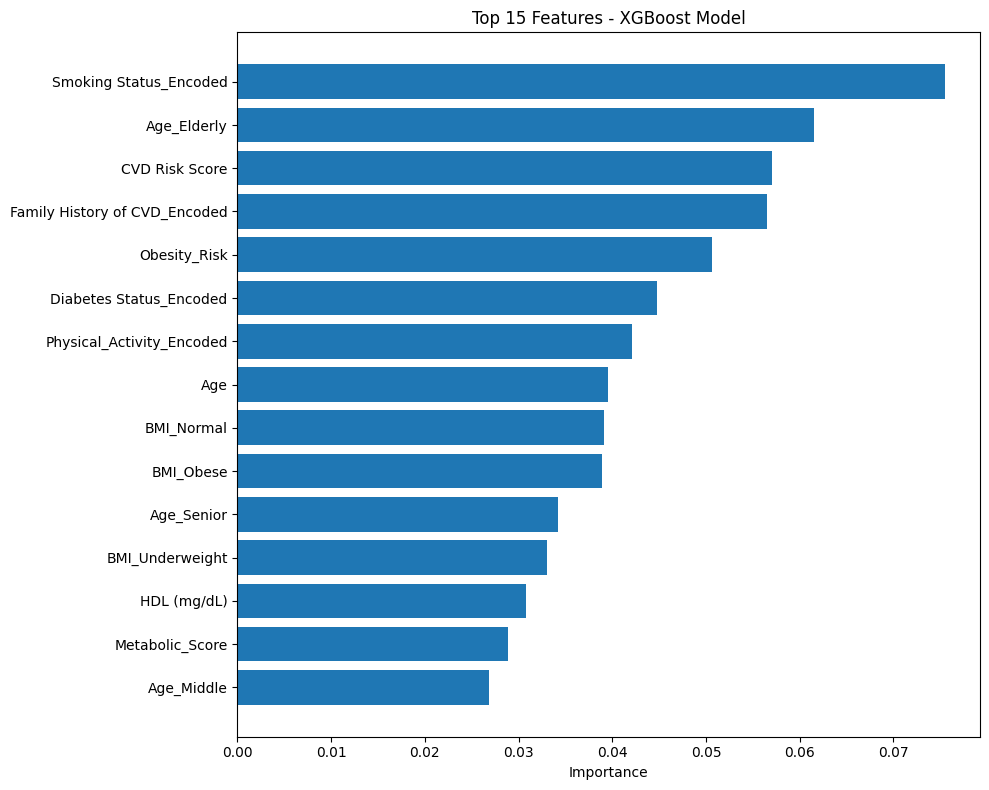

Feature importance saved.


In [4]:
# BLOCK 4: FEATURE IMPORTANCE
print("\n" + "="*60)
print("FINAL FEATURE IMPORTANCE ANALYSIS")
print("="*60)

importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top15 = importance_df.head(15)
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1])
plt.title('Top 15 Features - XGBoost Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/final_feature_importance.png')
plt.show()

importance_df.to_csv(f'{processed_path}feature_importance.csv', index=False)
print("Feature importance saved.")


In [5]:
# BLOCK 5: PREDICT ON SAMPLE PATIENTS
# Uses the same feature pipeline as predict.py
print("\n" + "="*60)
print("PREDICT ON SAMPLE PATIENTS")
print("="*60)

scaler = joblib.load(f'{processed_path}scaler.pkl')

scale_cols = ['Age','Weight (kg)','Height (m)','BMI',
              'Abdominal Circumference (cm)','Total Cholesterol (mg/dL)',
              'HDL (mg/dL)','Fasting Blood Sugar (mg/dL)',
              'Waist-to-Height Ratio','Systolic BP','Diastolic BP',
              'CVD Risk Score','Pulse Pressure','Cholesterol_HDL_Ratio',
              'Metabolic_Score','Physical_Activity_Encoded']
scale_cols = [c for c in scale_cols if c in feature_cols]

def build_patient_row(age, weight, height_m, bmi, abdominal,
                       total_chol, hdl, fbs, systolic, diastolic,
                       sex, smoking, diabetes, family_history, activity):
    sex_enc      = 0 if sex.upper()=='F' else 1
    smoking_enc  = 1 if smoking.upper()=='Y' else 0
    diabetes_enc = 1 if diabetes.upper()=='Y' else 0
    family_enc   = 1 if family_history.upper()=='Y' else 0
    act_enc      = {'Low':0,'Moderate':1,'High':2}.get(activity,1)
    bp_enc       = (0 if systolic<120 and diastolic<80 else
                    1 if systolic<130 and diastolic<80 else
                    2 if systolic<140 or diastolic<90 else 3)
    pulse        = systolic - diastolic
    chol_hdl     = total_chol / hdl if hdl>0 else 0
    obesity      = 1 if bmi>=30 else 0
    hypert       = 1 if (systolic>=140 or diastolic>=90) else 0
    metabolic    = (obesity + hypert +
                    (1 if total_chol>=240 else 0) +
                    (1 if fbs>=126 else 0) + smoking_enc)
    whr          = abdominal / (height_m*100)
    bmi_cat      = ('Underweight' if bmi<18.5 else 'Normal' if bmi<25
                    else 'Overweight' if bmi<30 else 'Obese')
    age_grp      = ('Young' if age<35 else 'Adult' if age<50
                    else 'Middle' if age<60 else 'Senior' if age<70 else 'Elderly')
    cvd_score    = float(np.clip(
        10.0 + 0.05*age + 0.01*(systolic-90) + 0.005*(total_chol-100)
        - 0.02*(hdl-30) + (1.0 if smoking_enc else 0)
        + (0.8 if diabetes_enc else 0) + (0.5 if family_enc else 0)
        + (0.3 if obesity else 0), 10.5, 24.2))

    row = {
        'Age':age,'Weight (kg)':weight,'Height (m)':height_m,'BMI':bmi,
        'Abdominal Circumference (cm)':abdominal,
        'Total Cholesterol (mg/dL)':total_chol,'HDL (mg/dL)':hdl,
        'Fasting Blood Sugar (mg/dL)':fbs,
        'Waist-to-Height Ratio':whr,'Systolic BP':systolic,'Diastolic BP':diastolic,
        'CVD Risk Score':cvd_score,'Pulse Pressure':pulse,
        'Cholesterol_HDL_Ratio':chol_hdl,'Obesity_Risk':obesity,
        'Hypertension_Risk':hypert,'Metabolic_Score':metabolic,
        'Sex_Encoded':sex_enc,'Smoking Status_Encoded':smoking_enc,
        'Diabetes Status_Encoded':diabetes_enc,
        'Family History of CVD_Encoded':family_enc,
        'Physical_Activity_Encoded':act_enc,'Blood_Pressure_Encoded':bp_enc,
        'BMI_Normal':1 if bmi_cat=='Normal' else 0,
        'BMI_Obese':1 if bmi_cat=='Obese' else 0,
        'BMI_Overweight':1 if bmi_cat=='Overweight' else 0,
        'BMI_Underweight':1 if bmi_cat=='Underweight' else 0,
        'Age_Adult':1 if age_grp=='Adult' else 0,
        'Age_Elderly':1 if age_grp=='Elderly' else 0,
        'Age_Middle':1 if age_grp=='Middle' else 0,
        'Age_Senior':1 if age_grp=='Senior' else 0,
        'Age_Young':1 if age_grp=='Young' else 0,
    }
    df_row = pd.DataFrame([row])[feature_cols]
    df_row[scale_cols] = scaler.transform(df_row[scale_cols])
    return df_row

def predict_and_print(name, df_row):
    proba    = best_model.predict_proba(df_row)[0]
    risk_pct = proba[1]*100
    label    = ('LOW RISK' if risk_pct<30 else
                'INTERMEDIARY RISK' if risk_pct<=70 else 'HIGH RISK')
    print(f"  {name}")
    print(f"    CVD Risk Score: {risk_pct:.1f}%  |  Label: {label}")
    print(f"    INTERMEDIARY: {proba[0]*100:.1f}%  |  HIGH: {proba[1]*100:.1f}%")

print("\nThresholds: <30% = LOW RISK | 30-70% = INTERMEDIARY | >70% = HIGH RISK\n")

# Patient 1: High risk
r1 = build_patient_row(62,95,1.70,32.9,105,265,35,148,155,98,'M','Y','Y','Y','Low')
predict_and_print("Patient 1 (62yr, obese, hypertensive, diabetic, smoker)", r1)

# Patient 2: Low risk
r2 = build_patient_row(28,62,1.72,21.0,74,155,72,82,112,72,'F','N','N','N','High')
predict_and_print("Patient 2 (28yr, healthy, active)", r2)

# Patient 3: Intermediary risk
r3 = build_patient_row(47,82,1.75,26.8,90,210,50,108,132,84,'M','N','N','Y','Moderate')
predict_and_print("Patient 3 (47yr, moderate risk factors)", r3)



PREDICT ON SAMPLE PATIENTS

Thresholds: <30% = LOW RISK | 30-70% = INTERMEDIARY | >70% = HIGH RISK

  Patient 1 (62yr, obese, hypertensive, diabetic, smoker)
    CVD Risk Score: 88.0%  |  Label: HIGH RISK
    INTERMEDIARY: 12.0%  |  HIGH: 88.0%
  Patient 2 (28yr, healthy, active)
    CVD Risk Score: 0.2%  |  Label: LOW RISK
    INTERMEDIARY: 99.8%  |  HIGH: 0.2%
  Patient 3 (47yr, moderate risk factors)
    CVD Risk Score: 21.6%  |  Label: LOW RISK
    INTERMEDIARY: 78.4%  |  HIGH: 21.6%


In [6]:
# BLOCK 6: SAVE EVALUATION RESULTS
print("\n" + "="*60)
print("SAVING EVALUATION RESULTS")
print("="*60)

# Load CV results saved by model building notebook
try:
    model_results = pd.read_csv(f'{processed_path}model_results.csv')
    xgb_row = model_results[model_results['Model']=='XGBoost'].iloc[0]
    cv_mean = xgb_row.get('CV_Mean', None)
    cv_std  = xgb_row.get('CV_Std', None)
except Exception:
    cv_mean, cv_std = None, None

results = {
    'Model':      'XGBoost',
    'Accuracy':   accuracy,
    'Precision':  precision,
    'Recall':     recall,
    'F1_Score':   f1,
    'AUC':        roc_auc,
    'CV_Mean':    cv_mean,
    'CV_Std':     cv_std,
    'Test_Samples': len(y_test),
    'Classes':    'INTERMEDIARY=0, HIGH=1 (LOW excluded by design)'
}
results_df = pd.DataFrame([results])
results_df.to_csv(f'{processed_path}model_results.csv', index=False)
print("Results saved to: model_results.csv")

# Classification report
report = classification_report(y_test, y_pred,
    target_names=['INTERMEDIARY','HIGH'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(f'{processed_path}classification_report.csv')
print("Classification report saved.")

print("\n" + "="*60)
print("MODEL EVALUATION COMPLETE")
print("="*60)
print(f"\n  Accuracy:  {accuracy*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")
print(f"  AUC:       {roc_auc*100:.2f}%")
if cv_mean:
    print(f"  CV Mean:   {cv_mean*100:.2f}% +/- {cv_std*100:.2f}%")



SAVING EVALUATION RESULTS
Results saved to: model_results.csv
Classification report saved.

MODEL EVALUATION COMPLETE

  Accuracy:  81.30%
  Precision: 81.26%
  Recall:    81.30%
  F1-Score:  81.27%
  AUC:       89.97%
  CV Mean:   76.83% +/- 13.39%
